In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sp
import time
import random
def print_np(x):
    print ("Type is %s" % (type(x)))
    print ("Shape is %s" % (x.shape,))
#     print ("Values are: \n%s" % (x))

In [2]:
import os
import sys
sys.path.append('../')

In [3]:
from model import UnicycleModel
from cost import UnicycleCost
from constraints import UnicycleConstraints
from matplotlib.patches import Ellipse
from utils.utils_alg import get_neighbor_vec,get_K_discrete
from utils.utils_alg import get_sample_eta_w,propagate_model
from utils.utils_plot import plot_traj,plot_traj_set,plot_state_input,plot_comparison

from trajopt import trajopt
from Scaling import TrajectoryScaling

import cvxpy as cvx

(CVXPY) Jan 30 01:04:20 PM: Encountered unexpected exception importing solver SCS:
ImportError("dlopen(/opt/anaconda3/envs/py309/lib/python3.9/site-packages/_scs_direct.cpython-39-darwin.so, 0x0002): Library not loaded: @rpath/liblapack.3.dylib\n  Referenced from: /opt/anaconda3/envs/py309/lib/python3.9/site-packages/_scs_direct.cpython-39-darwin.so\n  Reason: tried: '/opt/anaconda3/envs/py309/lib/python3.9/site-packages/../../liblapack.3.dylib' (no such file), '/opt/anaconda3/envs/py309/lib/python3.9/site-packages/../../liblapack.3.dylib' (no such file), '/opt/anaconda3/envs/py309/bin/../lib/liblapack.3.dylib' (no such file), '/opt/anaconda3/envs/py309/bin/../lib/liblapack.3.dylib' (no such file), '/usr/local/lib/liblapack.3.dylib' (no such file), '/usr/lib/liblapack.3.dylib' (no such file)")


In [4]:
N = 3
tf = 5
delT = tf/N

## obstacle setting

In [5]:
def get_H_obs(rx,ry) :
    return np.diag([1/rx,1/ry])
# obstacle
c_list = []
H_list = []
c1 = [1,2]
H1 = get_H_obs(0.75,1.5)
c_list.append(c1)
H_list.append(H1)
c2 = [4,3]
H2 = get_H_obs(0.75,1.5)
c_list.append(c2)
H_list.append(H2)

## initial and final conditions 

In [6]:
myModel = UnicycleModel.unicycle1('unicycle','analytic')

ix = myModel.ix
iu = myModel.iu
iw = myModel.iw
iq = myModel.iq
ip = myModel.ip

C = myModel.C
D = myModel.D
E = myModel.E
G = myModel.G

myCost = UnicycleCost.unicycle('Hello',ix,iu,N)
myConst = UnicycleConstraints.UnicycleConstraints('Hello',ix,iu)
myConst.set_obstacle(c_list,H_list)

In [7]:
xi = np.zeros(3)
xi[0] = 0.0
xi[1] = 0.0 
xi[2] = 0

xf = np.zeros(3)
xf[0] = 5.0
xf[1] = 5.0
xf[2] = 0

x0 = np.zeros((N+1,ix))
for i in range(N+1) :
    x0[i] = (N-i)/N * xi + i/N * xf
u0 = np.zeros((N+1,iu))

In [8]:
x_max = np.array([10,10,np.pi])
x_min = np.zeros(ix)

u_max = np.array([5,5])
u_min = np.zeros(iu)

traj_scaling = TrajectoryScaling(x_min,x_max,u_min,u_max,tf)

In [9]:
traj_solver= trajopt('unicycle',N,tf,20,myModel,myCost,myConst,Scaling=traj_scaling,
    type_discretization="foh",
    w_c=1,w_vc=1e3,w_tr=1e1,tol_vc=1e-6,tol_tr=1e-6,tol_dyn=1e-6,verbosity=True)

Is DPP?  True


In [10]:
_,_,xnom,unom,_,total_num_iter,_,_,_,_,history_nom = traj_solver.run(x0,u0,xi,xf)
tnom = np.array(range(N+1))*delT

Set parameter Username
Academic license - for non-commercial use only - expires 2023-11-07
┌──────────────────────────────────────────────────────────────────────────────────────────────┐

│                                              ..:: SCP ::..                                   │

├──────┬───────────┬──────────┬─────────┬───────────┬────────────┬─────────┬─────────┬─────────┤

│ iter │  total    │ final    │ input   │     -     │ total cost │ vc      │ tr      │ dyn     │

│      │  cost     │ time [s] │ energy  │     -     │ reduction  │ (log10) │         │         │

├──────┼───────────┼──────────┼─────────┼───────────┼────────────┼─────────┼─────────┼─────────┤

│1     │5005.460   │5.000     │3.72     │0          │-5.01e+03   │0(0.70  )│0(0.174 )│0(3.924 )│
│2     │10.982     │5.000     │6.37     │0          │4.99e+03    │1(-14.70)│0(0.461 )│0(1.994 )│
│3     │9.560      │5.000     │8.16     │0          │1.42        │1(-12.67)│0(0.140 )│0(1.027 )│
│4     │9.183      │5.000     

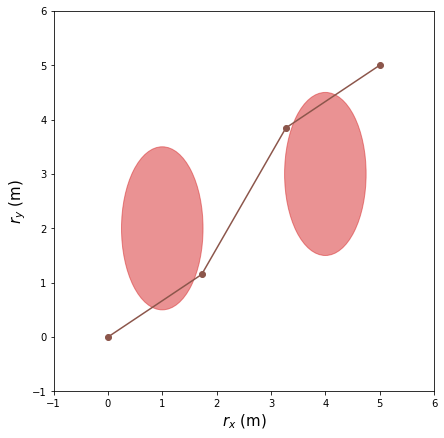

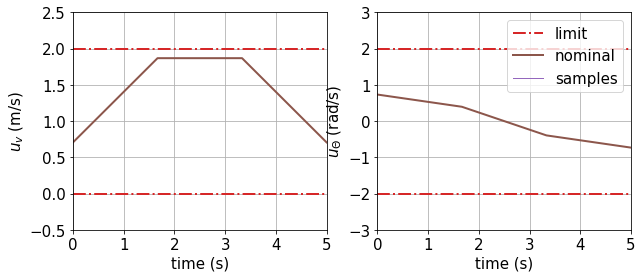

In [11]:
fS = 15
plt.figure(0,figsize=(15,7))
ax = plt.gca()
for ce,H in zip(c_list,H_list) :
    rx = 1/H[0,0]
    ry = 1/H[1,1]
    circle1 = Ellipse((ce[0],ce[1]),rx*2,ry*2,color='tab:red',alpha=0.5,fill=True)
    ax.add_patch(circle1)
plt.plot(xnom[:,0],xnom[:,1],'o-',color='tab:brown',label='traj w/o funnel')
# plot_traj_set(x0,u0,c_list,H_list,Q0,xi=xi,xf=xf,Qi=Qini,Qf=Qf,plt=plt)
plt.axis([-1.0, 6.0, -1.0, 6.0])
plt.gca().set_aspect('equal', adjustable='box')
plt.axis([-1.0, 6.0, -1.0, 6.0])
plt.xlabel('$r_x$ (m)', fontsize = fS)
plt.ylabel('$r_y$ (m)', fontsize = fS)


plt.figure(1,figsize=(10,4))
plt.subplot(121)
plt.plot(tnom, unom[:,0]*0+myConst.vmax,'-.',color='tab:red',alpha=1.0,linewidth=2.0,label='limit')
plt.plot(tnom, unom[:,0]*0+myConst.vmin,'-.',color='tab:red',alpha=1.0,linewidth=2.0)
plt.plot(tnom, unom[:,0],'-',color='tab:brown',alpha=1.0,linewidth=2.0,label='nominal')
plt.plot(1e3, 1e3,'-',color='tab:purple',alpha=1.0,linewidth=1.0,label='samples')
plt.xlabel('time (s)', fontsize = fS)
plt.ylabel('$u_v$ (m/s)', fontsize = fS)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.axis([0.0, tf, -0.5, 2.5])
plt.grid(True)

plt.subplot(122)
plt.plot(tnom, unom[:,1]*0+myConst.wmax,'-.',color='tab:red',alpha=1.0,linewidth=2.0)
plt.plot(tnom, unom[:,1]*0+myConst.wmin,'-.',color='tab:red',alpha=1.0,linewidth=2.0,label='limit')
plt.plot(tnom, unom[:,1],'-',color='tab:brown',alpha=1.0,linewidth=2.0,label='nominal')
plt.plot(1e3, 1e3,'-',color='tab:purple',alpha=1.0,linewidth=1.0,label='samples')
plt.xlabel('time (s)', fontsize = fS)
plt.ylabel('$u_{\Theta}$ (rad/s)', fontsize = fS)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.axis([0.0, tf, -3, 3])
plt.legend(fontsize=fS)
plt.rcParams["font.family"] = "Times New Roman"
plt.grid(True)

# funnel synthesis

In [46]:
# initialization
Anom,Bnom = myModel.diff(xnom,unom)
A,B,s,z,x_prop_n = myModel.diff_discrete_zoh(xnom[0:N,:],unom[0:N,:],delT,tf) 
S = np.eye(ix)
R = 1*np.eye(iu)
K0 = get_K_discrete(A,B,S,R,S,N,ix,iu)
K0 = np.vstack((K0,K0[-1:]))
Q0 = np.tile(np.diag([0.35**2,0.35**2,np.deg2rad(10)**2]),(N+1,1,1))
Y0 = K0@Q0

alpha = 0.0

In [47]:
x_max = np.array([1,1,np.pi])
x_min = np.zeros(ix)

u_max = np.array([5,5]) 
u_min = np.zeros(iu)

funl_scaling = TrajectoryScaling(x_min,x_max,u_min,u_max,tf)

In [48]:
from model.LMImodel import LMI_linear_systems, RK4

In [49]:
myLMI = LMI_linear_systems('test',ix,iu,alpha,"analytic")

In [50]:
# Qmax and Rmax
Qmax = []
for i in range(N+1) :
    Qmax.append(np.diag([0.4**2,0.4**2,np.deg2rad(20)**2]) * 5  ) 
Rmax = myConst.get_Rmax(unom)
Qf = np.diag([0.4**2,0.4**2,np.deg2rad(20)**2]) * 0.2

In [51]:
from funlopt_by_OCP import funlopt_by_OCP
from funlopt_by_COP import funlopt_by_COP

In [52]:
funl_solver1 = funlopt_by_OCP(ix,iu,0,0,0,N,delT,
                             myLMI,
                             funl_scaling,
                             myModel,
                             max_iter=1,
                             alpha=alpha)

funl_solver2 = funlopt_by_COP(ix,iu,0,0,0,N,delT,
                             funl_scaling,
                             myModel,
                             max_iter=1)

In [53]:
funl_solver1.cvx_initialize(Qf)
funl_solver2.cvx_initialize(alpha,Qf)

Is DPP?  True
Is DPP?  True


In [54]:
# Q1,K1,Y1,Z1,c1,xprop1 = funl_solver1.run(Q0,Y0,Q0,Qmax,Rmax,xnom,unom)
# _,_,_,_,c1,_ = funl_solver1.run(Q0,Y0,Q0,Qmax,Rmax,xnom,unom,flag_FOH=False)
# print(c1)
flag_FOH = False
Q1,K1,Y1,Z1,c1,xprop1 = funl_solver1.run(Q0,Y0,Q0,Qmax,Rmax,xnom,unom,flag_FOH=flag_FOH)
print(c1)

0.9566665728336855


In [55]:
from scipy.integrate import solve_ivp
from scipy import interpolate
Yfoh = interpolate.interp1d(tnom,Y1,axis=0)
Zfoh = interpolate.interp1d(tnom,Z1,axis=0)
idx_x = slice(0,ix)
idx_q = slice(ix,ix+ix*ix)

def dvdt(t,V,um,up,ym,yp,zm,zp,Anm=None,Anp=None,Bnm=None,Bnp=None) :
    alpha = (delT - t) / delT
    beta = t / delT
    u = alpha * um + beta * up
    y = alpha * ym + beta * yp
    z = alpha * zm + beta * zp
    
    x = V[idx_x]
    q = V[idx_q]
    if flag_FOH == False :
        A,B = myModel.diff(x,u)
    else :
        A = alpha * Anm + beta * Anp
        B = alpha * Bnm + beta * Bnp
    dxdt = myModel.forward(x,u).squeeze()
    dqdt = myLMI.forward(q,y,z,A,B)
    dV = np.hstack((dxdt,dqdt))
    return dV

tfwd = []
qfwd = []
xfwd = []
def vec(Q) :
    return Q.flatten('F')
for i in range(N) :
    V0 = np.zeros(ix+ix*ix)
    V0[idx_x] = xnom[i]
    V0[idx_q] = vec(Q1[i])
    
    if flag_FOH == False :
        sol = RK4(dvdt,(0,delT),V0,args=(unom[i],unom[i+1],
            vec(Y1[i]),vec(Y1[i+1]),
            vec(Z1[i]),vec(Z1[i+1]),
            ),N_RK=10)
    else :
        sol = RK4(dvdt,(0,delT),V0,args=(unom[i],unom[i+1],
            vec(Y1[i]),vec(Y1[i+1]),
            vec(Z1[i]),vec(Z1[i+1]),
            Anom[i],Anom[i+1],
            Bnom[i],Bnom[i+1]),N_RK=10)
    if i < N-1 :
        tsol,sol = sol.t[:-1],sol.y[:,:-1]
    else :
        tsol,sol = sol.t,sol.y
    tfwd.append(tsol+delT*i)
    xfwd.append(sol[idx_x,:].T)
    qfwd.append(sol[idx_q,:].T) #.reshape((ix,ix),order='F'))
tfwd = np.hstack(tfwd)
xfwd = np.vstack(xfwd)
qfwd = np.vstack(qfwd)
Qfwd = []
for q in qfwd :
    Qfwd.append(q.reshape((ix,ix),order='F'))
Qfwd = np.array(Qfwd)
Yfwd = Yfoh(tfwd)
Zfwd = Zfoh(tfwd)
Kfwd = []
for Q,Y in zip(Qfwd,Yfwd) :
    Kfwd.append(Y@np.linalg.inv(Q))
ufun = sp.interpolate.interp1d(tnom,unom,axis=0)
ufwd = ufun(tfwd)

Qtest_fwd = []

for Q,Y,Z,x,u in zip(Qfwd,Yfwd,Zfwd,xfwd,ufwd) :
    A,B = myModel.diff(x,u)
    dQ = myLMI.forward(Q,Y,Z,A,B)
#     Qtest = -dQ+A@Q+B@Y+Q@A.T+Y.T@B.T
    Qtest = Z
#     Qtest = dQ
    Qtest_fwd.append(Qtest)
Qtest_fwd = np.array(Qtest_fwd)
print_np(Qtest_fwd)
eig_Qtest,_ = np.linalg.eig(Qtest_fwd)
min_eig_Qtest = np.min(eig_Qtest,axis=1)
max_eig_Qtest = np.max(eig_Qtest,axis=1)

Type is <class 'numpy.ndarray'>
Shape is (28, 3, 3)


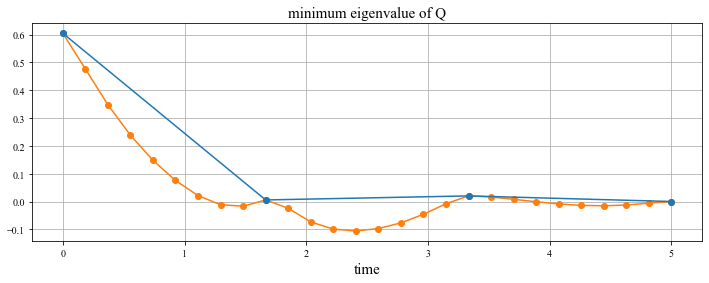

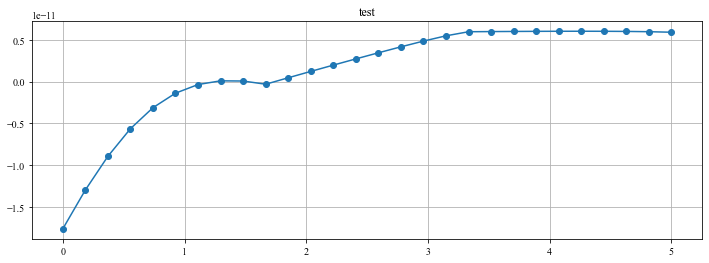

In [56]:
eig_Q1,_ = np.linalg.eig(Q1)
min_eig_Q1 = np.min(eig_Q1,axis=1)
eig_Qfwd,_ = np.linalg.eig(Qfwd)
min_eig_Qfwd = np.min(eig_Qfwd,axis=1)

plt.figure(figsize=(12,4))
plt.plot(tfwd,min_eig_Qfwd,'o-',color='tab:orange',label='inter')
plt.plot(tnom,min_eig_Q1,'o-',color='tab:blue')
# plt.plot(tfwd,tfwd*0,color='tab:red',label='indefinite')
plt.grid(True)
plt.title('minimum eigenvalue of Q',fontsize=15)
plt.xlabel('time',fontsize=15)

plt.figure(figsize=(12,4))
plt.plot(tfwd,min_eig_Qtest,'o-')
plt.title('test')
plt.grid(True)

In [23]:
# pick x such that V(x) < 0  at time around 4.5
t_test = tfwd[-3]
Q_test = Qfwd[-3]

Q_test_inv = np.linalg.inv(Q_test)
eig_test,eigvec_test = np.linalg.eig(Q_test_inv)
idx = 0
assert eigvec_test[idx].T@Q_test_inv@eigvec_test[idx] < 0
x_test = eigvec_test[idx]
print(x_test)

[-0.34144856  0.8997361   0.27182317]


In [ ]:
Afwd,Bfwd = myModel.diff(xfwd,ufwd)

AFOH_fun = sp.interpolate.interp1d(tnom,Anom,axis=0)
BFOH_fun = sp.interpolate.interp1d(tnom,Bnom,axis=0)
Afoh = AFOH_fun(tfwd)
Bfoh = BFOH_fun(tfwd)

Afwd_fro_norm = [np.linalg.norm(A,'fro') for A in Afwd]
Afoh_fro_norm = [np.linalg.norm(A,'fro') for A in Afoh]

In [ ]:
plt.figure(1,figsize=(10,10))
plt.subplot(221)
plt.plot(tfwd,Afwd[:,0,2],'-',color='tab:blue')
plt.plot(tfwd,Afoh[:,0,2],'--',color='tab:orange')
plt.title('A[0,2]',fontsize=15)
plt.subplot(222)
plt.plot(tfwd,Afwd[:,1,2],'-',color='tab:blue')
plt.plot(tfwd,Afoh[:,1,2],'--',color='tab:orange')
plt.title('A[1,2]',fontsize=15)
plt.subplot(223)
plt.plot(tfwd,Bfwd[:,0,0],'-',color='tab:blue')
plt.plot(tfwd,Bfoh[:,0,0],'--',color='tab:orange')
plt.title('B[0,0]',fontsize=15)
plt.subplot(223)
plt.plot(tfwd,Bfwd[:,0,0],'-',color='tab:blue')
plt.plot(tfwd,Bfoh[:,0,0],'--',color='tab:orange')
plt.title('B[0,0]',fontsize=15)
plt.subplot(224)
plt.plot(tfwd,Afwd_fro_norm,'-',color='tab:blue',label='True')
plt.plot(tfwd,Afoh_fro_norm,'--',color='tab:orange',label='FOH')
plt.title('norm(A) - frobenius',fontsize=15)
plt.legend(fontsize=15)

In [ ]:
Q2,K2,Y2,c2 = funl_solver2.run(Qmax,Rmax,xnom,unom)
print(c2)

In [ ]:
def get_state_margin_by_funnel(Q) :
    a1 = np.array([1,0,0])
    a2 = np.array([0,1,0])
    a3 = np.array([0,0,1])
    xfunl1 = []
    yfunl1 = []
    tfunl1 = []
    N = len(Q)-1
    for i in range(N+1) :
        xfunl1.append(np.sqrt(a1.T@Q[i]@a1))
        yfunl1.append(np.sqrt(a2.T@Q[i]@a2))
        tfunl1.append(np.sqrt(a3.T@Q[i]@a3))
    xfunl1 = np.array(xfunl1)
    yfunl1 = np.array(yfunl1)
    tfunl1 = np.array(tfunl1)
    return xfunl1,yfunl1,tfunl1
def get_input_margin_by_funnel(Q,K) :
    R1 = []
    N = len(Q)-1
    for i in range(N+1) :
        R1.append(K[i]@Q[i]@K[i].T)
    a1 = np.array([1,0])
    a2 = np.array([0,1])
    vfunl1 = []
    wfunl1 = []
    for i in range(N+1) :
        vfunl1.append(np.sqrt(a1.T@R1[i]@a1))
        wfunl1.append(np.sqrt(a2.T@R1[i]@a2))
    vfunl1 = np.array(vfunl1)
    wfunl1 = np.array(wfunl1)
    return vfunl1,wfunl1

xfunl1,yfunl1,thfunl1 = get_state_margin_by_funnel(Q1)
xfunl2,yfunl2,thfunl2 = get_state_margin_by_funnel(Q2)

vfunl1,wfunl1 = get_input_margin_by_funnel(Q1,K1)
vfunl2,wfunl2 = get_input_margin_by_funnel(Q2,K2)

In [ ]:
plt.figure(figsize=(12,7))
plt.subplot(121)
plot_traj_set(xnom,unom,c_list,H_list,Q1,xf=xnom[-1],Qf=Qf,plt=plt)
# plot_traj_set(xfwd,unom,c_list,H_list,Qfwd,xf=xnom[-1],Qf=Qf,plt=plt)
plt.subplot(122)
plot_traj_set(xnom,unom,c_list,H_list,Q2,xf=xnom[-1],Qf=Qf,plt=plt)

In [ ]:
xfunl_fwd,yfunl_fwd,thfunl_fwd = get_state_margin_by_funnel(Qfwd)

vfunl_fwd,wfunl_fwd = get_input_margin_by_funnel(Qfwd,Kfwd)

In [ ]:
plt.figure(1,figsize=(15,4))
plt.subplot(131)
plt.plot(tnom, xnom[:,0],'o',color='tab:brown',alpha=1.0,linewidth=2.0)
plt.plot(tfwd, xfwd[:,0],'-',color='tab:brown',alpha=1.0,linewidth=2.0,label='nominal')

plt.plot(tnom, xnom[:,0]+xfunl1,'o',color='tab:blue',alpha=1.0,linewidth=2.0)
plt.plot(tnom, xnom[:,0]-xfunl1,'o',color='tab:blue',alpha=1.0,linewidth=2.0)
plt.plot(tfwd, xfwd[:,0]+xfunl_fwd,'-',color='tab:blue',alpha=1.0,linewidth=2.0,label='OCP')
plt.plot(tfwd, xfwd[:,0]-xfunl_fwd,'-',color='tab:blue',alpha=1.0,linewidth=2.0)

plt.plot(tnom, xnom[:,0]+xfunl2,'--',color='tab:orange',alpha=1.0,linewidth=2.0,label='CO')
plt.plot(tnom, xnom[:,0]-xfunl2,'--',color='tab:orange',alpha=1.0,linewidth=2.0)

plt.xlabel('time (s)', fontsize = fS)
plt.ylabel('$x$ (m/s)', fontsize = fS)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.axis([0.0, tf, -0.5, 5.5])
plt.grid(True)

plt.subplot(132)
plt.plot(tnom, xnom[:,1],'o',color='tab:brown',alpha=1.0,linewidth=2.0)
plt.plot(tfwd, xfwd[:,1],'-',color='tab:brown',alpha=1.0,linewidth=2.0,label='nominal')

plt.plot(tnom, xnom[:,1]+yfunl1,'o',color='tab:blue',alpha=1.0,linewidth=2.0)
plt.plot(tnom, xnom[:,1]-yfunl1,'o',color='tab:blue',alpha=1.0,linewidth=2.0)
plt.plot(tfwd, xfwd[:,1]+yfunl_fwd,'-',color='tab:blue',alpha=1.0,linewidth=2.0,label='OCP')
plt.plot(tfwd, xfwd[:,1]-yfunl_fwd,'-',color='tab:blue',alpha=1.0,linewidth=2.0)

plt.plot(tnom, xnom[:,1]+yfunl2,'--',color='tab:orange',alpha=1.0,linewidth=2.0,label='CO')
plt.plot(tnom, xnom[:,1]-yfunl2,'--',color='tab:orange',alpha=1.0,linewidth=2.0)

plt.xlabel('time (s)', fontsize = fS)
plt.ylabel('$y$ (m/s)', fontsize = fS)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.axis([0.0, tf, -0.5, 5.5])
plt.grid(True)

plt.subplot(133)
plt.plot(tnom, xnom[:,2],'o',color='tab:brown',alpha=1.0,linewidth=2.0)
plt.plot(tfwd, xfwd[:,2],'-',color='tab:brown',alpha=1.0,linewidth=2.0,label='nominal')

plt.plot(tnom, xnom[:,2]+thfunl1,'o',color='tab:blue',alpha=1.0,linewidth=2.0)
plt.plot(tnom, xnom[:,2]-thfunl1,'o',color='tab:blue',alpha=1.0,linewidth=2.0)
plt.plot(tfwd, xfwd[:,2]+thfunl_fwd,'-',color='tab:blue',alpha=1.0,linewidth=2.0,label='OCP')
plt.plot(tfwd, xfwd[:,2]-thfunl_fwd,'-',color='tab:blue',alpha=1.0,linewidth=2.0)

plt.plot(tnom, xnom[:,2]+thfunl2,'--',color='tab:orange',alpha=1.0,linewidth=2.0,label='CO')
plt.plot(tnom, xnom[:,2]-thfunl2,'--',color='tab:orange',alpha=1.0,linewidth=2.0)

plt.xlabel('time (s)', fontsize = fS)
plt.ylabel('$theta$ (rad)', fontsize = fS)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.axis([0.0, tf, -np.deg2rad(90), np.deg2rad(120)])
plt.legend(fontsize=fS)
plt.rcParams["font.family"] = "Times New Roman"
plt.grid(True)


In [ ]:
plt.figure(1,figsize=(15,4))
plt.subplot(121)
plt.plot(tnom, unom[:,0]*0+myConst.vmax,'-.',color='tab:red',alpha=1.0,linewidth=2.0,label='limit')
plt.plot(tnom, unom[:,0]*0+myConst.vmin,'-.',color='tab:red',alpha=1.0,linewidth=2.0)

plt.plot(tnom, unom[:,0],'o',color='tab:brown',alpha=1.0,linewidth=2.0)
plt.plot(tfwd, ufwd[:,0],'-',color='tab:brown',alpha=1.0,linewidth=2.0,label='nominal')

plt.plot(tnom, unom[:,0]+vfunl1,'o',color='tab:blue',alpha=1.0,linewidth=2.0)
plt.plot(tnom, unom[:,0]-vfunl1,'o',color='tab:blue',alpha=1.0,linewidth=2.0)

plt.plot(tfwd, ufwd[:,0]+vfunl_fwd,'-',color='tab:blue',alpha=1.0,linewidth=2.0,label='OCP')
plt.plot(tfwd, ufwd[:,0]-vfunl_fwd,'-',color='tab:blue',alpha=1.0,linewidth=2.0)

plt.plot(tnom, unom[:,0]+vfunl2,'--',color='tab:orange',alpha=1.0,linewidth=2.0,label='CO')
plt.plot(tnom, unom[:,0]-vfunl2,'--',color='tab:orange',alpha=1.0,linewidth=2.0)

plt.xlabel('time (s)', fontsize = fS)
plt.ylabel('$u_v$ (m/s)', fontsize = fS)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.axis([0.0, tf, -0.5, 2.5])
plt.grid(True)

plt.subplot(122)
plt.plot(tnom, unom[:,1]*0+myConst.wmax,'-.',color='tab:red',alpha=1.0,linewidth=2.0)
plt.plot(tnom, unom[:,1]*0+myConst.wmin,'-.',color='tab:red',alpha=1.0,linewidth=2.0,label='limit')

plt.plot(tnom, unom[:,1],'o',color='tab:brown',alpha=1.0,linewidth=2.0)
plt.plot(tfwd, ufwd[:,1],'-',color='tab:brown',alpha=1.0,linewidth=2.0,label='nominal')

plt.plot(tnom, unom[:,1]+wfunl1,'o',color='tab:blue',alpha=1.0,linewidth=2.0)
plt.plot(tnom, unom[:,1]-wfunl1,'o',color='tab:blue',alpha=1.0,linewidth=2.0)

plt.plot(tfwd, ufwd[:,1]+wfunl_fwd,'-',color='tab:blue',alpha=1.0,linewidth=2.0,label='OCP')
plt.plot(tfwd, ufwd[:,1]-wfunl_fwd,'-',color='tab:blue',alpha=1.0,linewidth=2.0)

plt.plot(tnom, unom[:,1]+wfunl2,'--',color='tab:orange',alpha=1.0,linewidth=2.0,label='CO')
plt.plot(tnom, unom[:,1]-wfunl2,'--',color='tab:orange',alpha=1.0,linewidth=2.0)

plt.xlabel('time (s)', fontsize = fS)
plt.ylabel('$u_{\Theta}$ (rad/s)', fontsize = fS)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.axis([0.0, tf, -3, 3])
plt.legend(fontsize=fS)
plt.rcParams["font.family"] = "Times New Roman"
plt.grid(True)


In [ ]:
np.linalg.eig(np.array([[0,1,0],[-1,0,-1],[0,1,0]]))